#### [ AlexNet Image Classifiction Model ]
- 데이터셋 : ImageNet의 1000개 카테고리 이미지 사용
- 2012년 우승모델

In [3]:
## 모듈 로딩
import torch
from torchvision.models import *    ## 사전학습 내장 모델 클래스 관련
from torchinfo import summary       ## 모델 정보 확인용

In [5]:
## 모델 인스턴스 생성
model = alexnet(weights='DEFAULT')

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to C:\Users\kdt/.cache\torch\hub\checkpoints\alexnet-owt-7be5be79.pth
100.0%


In [8]:
summary(model, input_size=(1,3,244,244) )

Layer (type:depth-idx)                   Output Shape              Param #
AlexNet                                  [1, 1000]                 --
├─Sequential: 1-1                        [1, 256, 6, 6]            --
│    └─Conv2d: 2-1                       [1, 64, 60, 60]           23,296
│    └─ReLU: 2-2                         [1, 64, 60, 60]           --
│    └─MaxPool2d: 2-3                    [1, 64, 29, 29]           --
│    └─Conv2d: 2-4                       [1, 192, 29, 29]          307,392
│    └─ReLU: 2-5                         [1, 192, 29, 29]          --
│    └─MaxPool2d: 2-6                    [1, 192, 14, 14]          --
│    └─Conv2d: 2-7                       [1, 384, 14, 14]          663,936
│    └─ReLU: 2-8                         [1, 384, 14, 14]          --
│    └─Conv2d: 2-9                       [1, 256, 14, 14]          884,992
│    └─ReLU: 2-10                        [1, 256, 14, 14]          --
│    └─Conv2d: 2-11                      [1, 256, 14, 14]         

In [11]:
for name, param in model.named_parameters():
    print(name, param.shape)

features.0.weight torch.Size([64, 3, 11, 11])
features.0.bias torch.Size([64])
features.3.weight torch.Size([192, 64, 5, 5])
features.3.bias torch.Size([192])
features.6.weight torch.Size([384, 192, 3, 3])
features.6.bias torch.Size([384])
features.8.weight torch.Size([256, 384, 3, 3])
features.8.bias torch.Size([256])
features.10.weight torch.Size([256, 256, 3, 3])
features.10.bias torch.Size([256])
classifier.1.weight torch.Size([4096, 9216])
classifier.1.bias torch.Size([4096])
classifier.4.weight torch.Size([4096, 4096])
classifier.4.bias torch.Size([4096])
classifier.6.weight torch.Size([1000, 4096])
classifier.6.bias torch.Size([1000])


In [12]:
## AlexNet 모델을 사용한 이미지 분류
## 모델이 인식하는 형태로 이미지 전처리 필요
import torchvision.transforms as transforms

In [ ]:
preprocessing = transforms.Compose([
                                    transforms.Resize((256,256)),
                                    transforms.CenterCrop((224,224)),
                                    
                                    transforms.ToTensor(),
                                    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [14]:
weights = AlexNet_Weights.DEFAULT
preprocess = weights.transforms()
preprocess

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [22]:
CLASSES = weights.meta['categories']
CLASSES

IDX_TO_CLASS = dict(zip(range(1000), CLASSES))
IDX_TO_CLASS

{0: 'tench',
 1: 'goldfish',
 2: 'great white shark',
 3: 'tiger shark',
 4: 'hammerhead',
 5: 'electric ray',
 6: 'stingray',
 7: 'cock',
 8: 'hen',
 9: 'ostrich',
 10: 'brambling',
 11: 'goldfinch',
 12: 'house finch',
 13: 'junco',
 14: 'indigo bunting',
 15: 'robin',
 16: 'bulbul',
 17: 'jay',
 18: 'magpie',
 19: 'chickadee',
 20: 'water ouzel',
 21: 'kite',
 22: 'bald eagle',
 23: 'vulture',
 24: 'great grey owl',
 25: 'European fire salamander',
 26: 'common newt',
 27: 'eft',
 28: 'spotted salamander',
 29: 'axolotl',
 30: 'bullfrog',
 31: 'tree frog',
 32: 'tailed frog',
 33: 'loggerhead',
 34: 'leatherback turtle',
 35: 'mud turtle',
 36: 'terrapin',
 37: 'box turtle',
 38: 'banded gecko',
 39: 'common iguana',
 40: 'American chameleon',
 41: 'whiptail',
 42: 'agama',
 43: 'frilled lizard',
 44: 'alligator lizard',
 45: 'Gila monster',
 46: 'green lizard',
 47: 'African chameleon',
 48: 'Komodo dragon',
 49: 'African crocodile',
 50: 'American alligator',
 51: 'triceratops',
 

In [26]:
import os

IMG_DIR = '../_data/image/'
IMG_LIST = os.listdir(IMG_DIR)
IMG_LIST = [IMG_DIR+x for x in IMG_LIST if x.endswith('jpg')]

IMG_LIST

['../_data/image/beach wagon.jpg',
 '../_data/image/French horn.jpg',
 '../_data/image/great grey owl.jpg',
 '../_data/image/hartebeest.jpg',
 '../_data/image/measuring cup.jpg']

<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=225x225 at 0x20FAA8E1DF0>
torch.Size([3, 224, 224])
tensor(895)
895
warplane


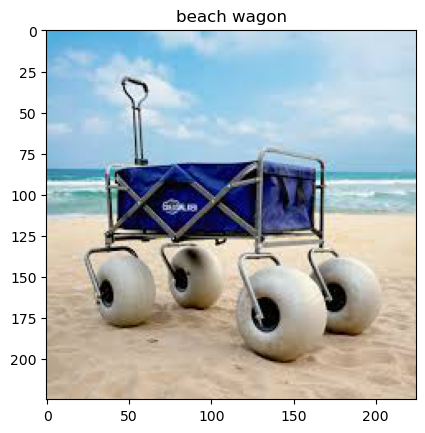

<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=281x180 at 0x20FAA7825E0>
torch.Size([3, 224, 224])
tensor(566)
566
French horn


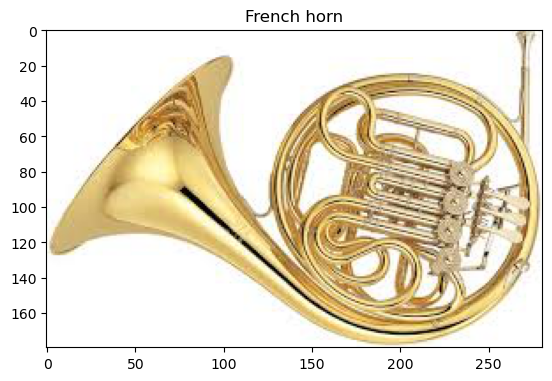

<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=309x163 at 0x20FAA789310>
torch.Size([3, 224, 224])
tensor(24)
24
great grey owl


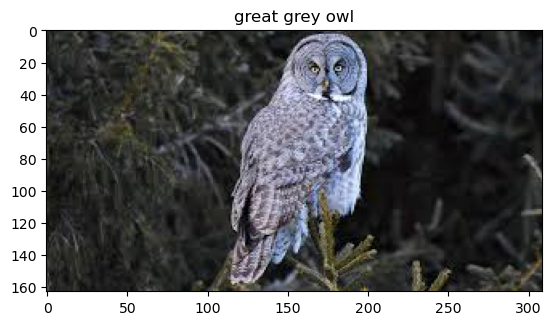

<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=202x250 at 0x20FAA69B670>
torch.Size([3, 224, 224])
tensor(339)
339
sorrel


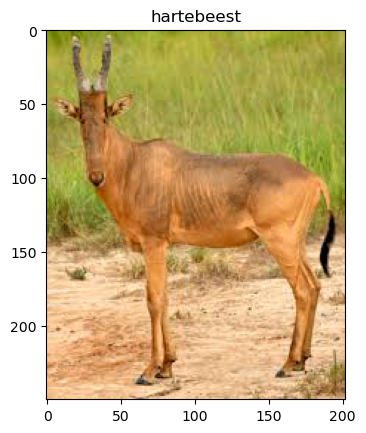

<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=225x225 at 0x20FA8CE4C10>
torch.Size([3, 224, 224])
tensor(647)
647
measuring cup


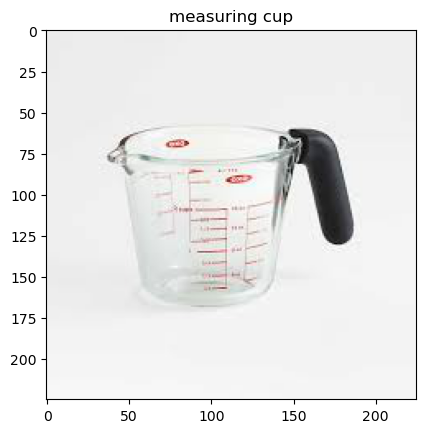

In [50]:
## 이미지 데이터 로딩 후 전처리 => 모델 => 예측값 체크

from PIL import Image
import matplotlib.pyplot as plt
for imgfile in IMG_LIST:
    
    img = Image.open(imgfile)
    print(img)
    img_transe = preprocess(img)
    print(img_transe.shape)
    
    img_transe.unsqueeze_(0)
    pre = model(img_transe)
    print(pre.argmax())
    print(pre.max(dim=1)[1].item())
    print(IDX_TO_CLASS[pre.argmax().item()])
    plt.imshow(img)
    plt.title(imgfile.split('/')[3][:-4])
    plt.show()




In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
tensors = []

